In [12]:
%matplotlib inline


In [3]:
import simpy
import random
import statistics
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
JUMLAH_OMPRENG = 180

# Data penyimpanan
data = {
    "Lauk": [],
    "Angkat": [],
    "Nasi": [],
    "Total": []
}

waktu_selesai = []


In [5]:
def proses_ompreng(env, lauk, angkat, nasi):
    mulai = env.now

    # Tahap 1: Isi Lauk
    with lauk.request() as req:
        yield req
        t = random.uniform(0.5, 1)
        data["Lauk"].append(t)
        yield env.timeout(t)

    # Tahap 2: Angkat Ompreng
    with angkat.request() as req:
        yield req
        t = random.uniform(0.33, 1)
        data["Angkat"].append(t)
        yield env.timeout(t)

    # Tahap 3: Tambah Nasi
    with nasi.request() as req:
        yield req
        t = random.uniform(0.5, 1)
        data["Nasi"].append(t)
        yield env.timeout(t)

    total = env.now - mulai
    data["Total"].append(total)
    waktu_selesai.append(env.now)


In [6]:
def generator(env, lauk, angkat, nasi):
    for _ in range(JUMLAH_OMPRENG):
        env.process(proses_ompreng(env, lauk, angkat, nasi))
        yield env.timeout(0.1)

env = simpy.Environment()

lauk = simpy.Resource(env, capacity=2)
angkat = simpy.Resource(env, capacity=2)
nasi = simpy.Resource(env, capacity=3)

env.process(generator(env, lauk, angkat, nasi))
env.run()


In [7]:
print("Total Waktu Piket (menit) :", round(max(waktu_selesai), 2))
print("Rata-rata Waktu per Ompreng :", round(statistics.mean(data["Total"]), 2))
print("Waktu Tercepat :", round(min(data["Total"]), 2))
print("Waktu Terlama :", round(max(data["Total"]), 2))


Total Waktu Piket (menit) : 67.06
Rata-rata Waktu per Ompreng : 25.49
Waktu Tercepat : 2.05
Waktu Terlama : 49.46


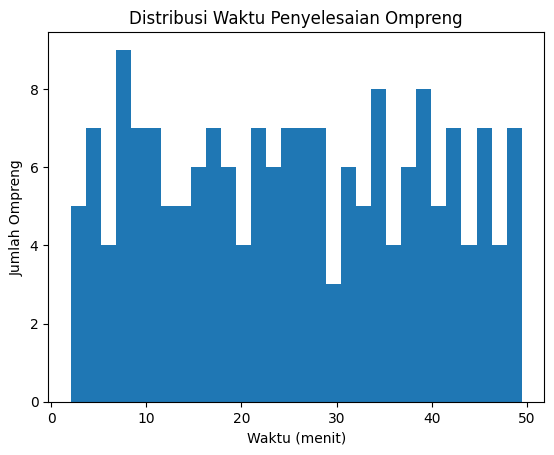

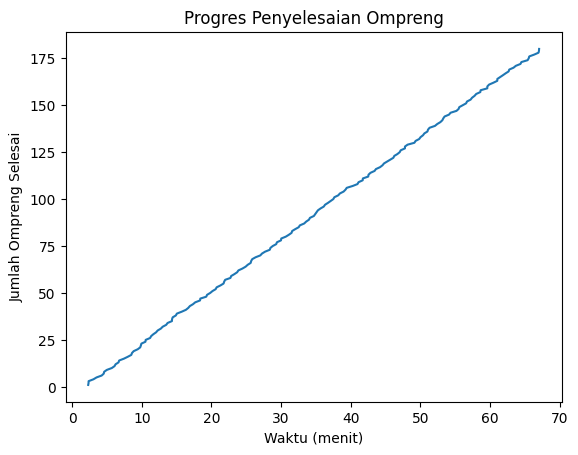

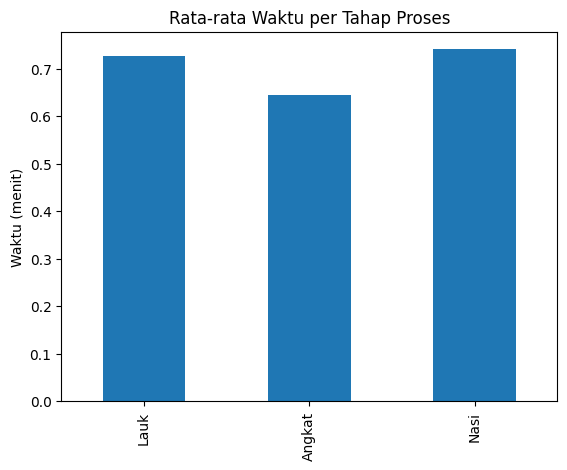

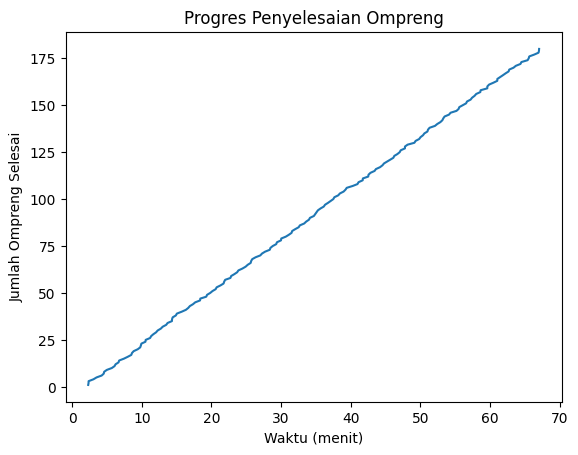

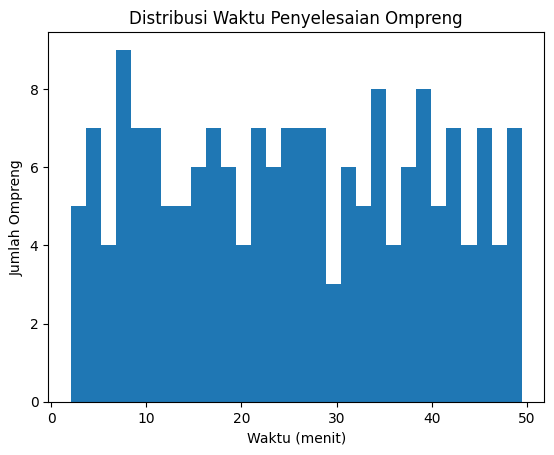

In [13]:
df = pd.DataFrame(data)

plt.figure()
plt.hist(df["Total"], bins=30)
plt.title("Distribusi Waktu Penyelesaian Ompreng")
plt.xlabel("Waktu (menit)")
plt.ylabel("Jumlah Ompreng")
plt.show()


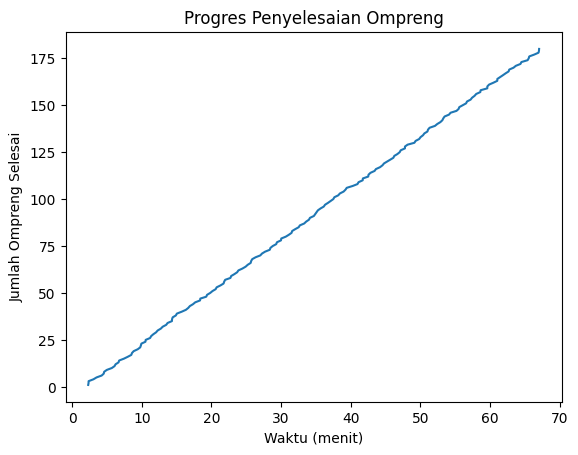

In [14]:
df_progress = pd.DataFrame({
    "Waktu": sorted(waktu_selesai),
    "Ompreng Selesai": range(1, len(waktu_selesai) + 1)
})

plt.figure()
plt.plot(df_progress["Waktu"], df_progress["Ompreng Selesai"])
plt.title("Progres Penyelesaian Ompreng")
plt.xlabel("Waktu (menit)")
plt.ylabel("Jumlah Ompreng Selesai")
plt.show()


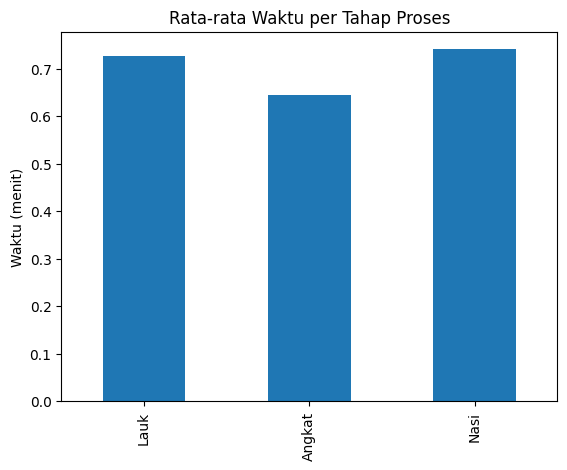

In [15]:
mean_stage = df[["Lauk", "Angkat", "Nasi"]].mean()

plt.figure()
mean_stage.plot(kind="bar")
plt.title("Rata-rata Waktu per Tahap Proses")
plt.ylabel("Waktu (menit)")
plt.show()
